# Assignment 1: NLP Fundamentals

Instructor: Fatemeh Dehrouyeh

Author: Yun-Jiung Wang

Student Number: 1256222

Date: Feb 17th, 2026


## 1. Part A - Theoretical

### Question 1.1: Describe how TF–IDF weighting reduces the importance of common words. Provide an example using any short text

Ans:

TF (Term Frequency) is used on calculating how often a word appears in 1 document.

IDF (Inverse Document Frequency) used on calculating how rare a word appers in all documents.

TF-IDF: is a balancing act between two metrics

**Example:**

Given a corpus of 100 documents about technology.


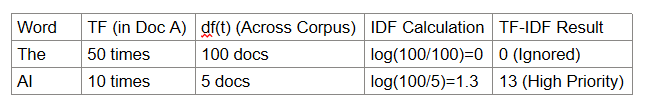


Even "The" appears 5 times more often than "AI" in Document A, its TF-IDF weight is 0 because it provides no unique information. "AI" is rare across the collection, so it is identified as a key feature.





### Question 1.2: What problem do polysemy and ambiguity create in NLP? Give one example for each.

Ans:

The problem that polysemy and amniguity create is that it is difficult for computer to identify correct context, causing errors in translation, sentiment analysis, or search results.

**Examples:**

Polysemy: The word "Apple" can refer to a fruit or a technology company.

Ambiguity: "Flying planes can be dangerous." This could refer to the act of flying is dangerous, or that planes that are flying are dangerous.

### Question 1.3: Compare BM25 and the Vector Space Model in Information Retrieval

Ans:

**Vector Space Model:**

Represent documents and queries as vectors in a high-dimensional space. The distance between these vectors determines relevance. Useing TF-IDF as the weighting scheme.

Pros: Simple, mathematically elegant, and captures global term importance via IDF.

Cons: Assumes term frequency grows linearly with relevance, which is often untrue in real-world text.

**BM25 (Best Matching 25):**

A "probabilistic" model, considered an evolution of TF-IDF/VSM and is the default ranking algorithm for modern search engines like Elasticsearch and Lucene.

Pros: Handling Term Frequency Saturation and Document Length Normalization.

Corns: A bit more complex compare to VSM.

**Summary:**

In VSM (TF-IDF), if a document mentions "Apple" 100 times, it gets a high score. However, in BM25, the model identifing the mention "Apple" 20 times is likely just as relevant as 100 times.

The VSC uses geometry and TF-IDF to calculate relevance, and BM25 improves upon it by introducing TF saturation and document length normalization. This makes BM25 more robust in real-world scenarios where longer documents or repetitive words might otherwise bias the results




### Question 1.4: What is FastText, and how does it differ from traditional word embedding models such as Word2Vec?

Ans: 

FastText is an extension of the Word2Vec model, it represents each word as a bag of character n-grams. On the other hand, Word2Vec treats each word as an atomic unit.

The differences between them:

1. Subword Information:

Word2Vec (Word-level) - Each word has its own unique vector. For "apple" and "apples" are treated as two different keys in a map.

FastText (Character-level) - Each word is broken down into sub-parts. For "apple", it looks at ap, app, ppl, etc. The final word vector is the sum of these n-gram vectors.

2. Handling OOV (Out-of-Vocabulary):

Word2Vec - The model cannot generate a vector for a word that doesnot exit in the training data, and will throw a KeyError.

FastText - It can construct the new words' vector by conbining the vectors of its known n-grams.

3. Morphological Richness: 

FastText performs better for languages with many word forms (like German or even English suffixes) due to sharing information across similar word structures.







## Part B - Coding

In [19]:
# !pip install gensim

Import libs

In [20]:
# --- Question 5: spaCy & NLP Analysis ---
import spacy
from spacy import displacy  # visiualize Parse Tree

# --- Question 6: NLTK, Stemming & Lemmatization ---
import nltk
from nltk.corpus import gutenberg
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
import string
import random  # using random.choice() for random sampling

# --- Question 7: Regular Expressions ---
import re

# --- Question 8: Word Embeddings (Gensim) ---
from gensim.models import Word2Vec, FastText
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

In [21]:
nltk.download('gutenberg')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package gutenberg to
[nltk_data]     C:\Users\virwa\AppData\Roaming\nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\virwa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\virwa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\virwa\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\virwa\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\virwa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### 2.1 Question 5:

Given the sentence: “Dr. Smith prescribed medicine to treat the patient on Monday.”

#### a) Use spaCy to generate the dependency parse tree.

#### b) Identify the POS tags and named entities.

In [22]:
from IPython.core.display import display, HTML
# 1. Load the English model
nlp = spacy.load("en_core_web_sm")
# 2. Define the input sentence
sen = "Dr. Smith prescribed medicine to treat the patient on Monday."

# 3. Process the sentence with spaCy
doc = nlp(sen)

#a) Use spaCy to generate the dependency parse tree.
html = displacy.render(doc, style="dep", jupyter=False, options={"distance": 100})
scaled_html = f'<div style="zoom: 0.8; overflow-x: auto;">{html}</div>'
display(HTML(scaled_html))  # Display the scaled HTML in Jupyter Notebook

# b) Identify the POS tags and named entities.
print("POS tags and named entities:\n")
for token in doc:
    print(f"{token.text}: {token.pos_}, {token.ent_type_}")


POS tags and named entities:

Dr.: PROPN, 
Smith: PROPN, PERSON
prescribed: VERB, 
medicine: NOUN, 
to: PART, 
treat: VERB, 
the: DET, 
patient: NOUN, 
on: ADP, 
Monday: PROPN, DATE
.: PUNCT, 



#### c) Explain how dependency parsing helps in question answering systems.

Dependency parsing helps QA systems move beyond just "keyword matching." Instead of just looking for the same words, the system understands the grammar and meaning, which leads to much more accurate answers.

#### d) Identify one example of ambiguity or polysemy and describe how context resolves it

**Polysemy:** One word has two or more related meanings.

**Ambiguity:** A phrase or sentence can be understood in more than one way.

**Example:**

Given the word "bank", it could mean the "Financial Bank" or it could also means the "River Bank".

**Problem:** Given the sentence "I am going to the bank." This is ambiguous. Both human and computer cannot tell if I am going to deposit a check or go fishing. More informations are needed to understand the true meaning.

**Solition:**

Context is the additional information in the sentence or the situation. Usually look for neighboring words to solve the mystery.

Case1: "I am going to the bank to withdraw some cash."

With the context words: withdraw, cash; both system and human are able to understand this is the finalcial meaning.

Case2: "I sat on the grassy bank and put my feet in the water."

With the context words" grassy and water; system can recogonize the "bank" here in the sentence means "River BanK".




###  2.2 Question 6:

Use a short public-domain text from the NLTK gutenberg corpus (for example, “Emma” by Jane Austen). The first 3000 characters are sufficient for this task.

Load raw text of "Emma" by Jane Austen from the Gutenberg corpus and take the first 3000 characters as sample

In [23]:
raw_text = gutenberg.raw('austen-emma.txt') # Load the raw text of "Emma" by Jane Austen from the Gutenberg corpus
sample_text = raw_text[:3000] # Take the first 3000 characters as a sample for analysis
print(sample_text[:500]) # Print the sample text to verify its content

[Emma by Jane Austen 1816]

VOLUME I

CHAPTER I


Emma Woodhouse, handsome, clever, and rich, with a comfortable home
and happy disposition, seemed to unite some of the best blessings
of existence; and had lived nearly twenty-one years in the world
with very little to distress or vex her.

She was the youngest of the two daughters of a most affectionate,
indulgent father; and had, in consequence of her sister's marriage,
been mistress of his house from a very early period.  Her mother
had died t


#### a) Tokenize, convert to lowercase, and remove stopwords and punctuation.

In [24]:
tokens = word_tokenize(sample_text.lower()) # Lowercase the text and tokenize it into words
stop_words = set(stopwords.words('english'))
cleaned_tokens = [w for w in tokens if w not in stop_words and w not in string.punctuation]
print("cleaned_tokens:\n",cleaned_tokens)

cleaned_tokens:
 ['emma', 'jane', 'austen', '1816', 'volume', 'chapter', 'emma', 'woodhouse', 'handsome', 'clever', 'rich', 'comfortable', 'home', 'happy', 'disposition', 'seemed', 'unite', 'best', 'blessings', 'existence', 'lived', 'nearly', 'twenty-one', 'years', 'world', 'little', 'distress', 'vex', 'youngest', 'two', 'daughters', 'affectionate', 'indulgent', 'father', 'consequence', 'sister', "'s", 'marriage', 'mistress', 'house', 'early', 'period', 'mother', 'died', 'long', 'ago', 'indistinct', 'remembrance', 'caresses', 'place', 'supplied', 'excellent', 'woman', 'governess', 'fallen', 'little', 'short', 'mother', 'affection', 'sixteen', 'years', 'miss', 'taylor', 'mr.', 'woodhouse', "'s", 'family', 'less', 'governess', 'friend', 'fond', 'daughters', 'particularly', 'emma', '_them_', 'intimacy', 'sisters', 'even', 'miss', 'taylor', 'ceased', 'hold', 'nominal', 'office', 'governess', 'mildness', 'temper', 'hardly', 'allowed', 'impose', 'restraint', 'shadow', 'authority', 'long', 'p

#### b) Apply both stemming (PorterStemmer) and lemmatization (WordNetLemmatizer).

In [25]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Apply stemming and lemmatization to the cleaned tokens
stemmed_tokens = [stemmer.stem(w) for w in cleaned_tokens]
lemmatized_tokens = [lemmatizer.lemmatize(w) for w in cleaned_tokens]
print("Stemmed Tokens:\n", stemmed_tokens[:10])
print("Lemmatized Tokens:\n", lemmatized_tokens[:10])

Stemmed Tokens:
 ['emma', 'jane', 'austen', '1816', 'volum', 'chapter', 'emma', 'woodhous', 'handsom', 'clever']
Lemmatized Tokens:
 ['emma', 'jane', 'austen', '1816', 'volume', 'chapter', 'emma', 'woodhouse', 'handsome', 'clever']


#### c) Compare the results for 10 randomly selected words and discuss the differences.

In [26]:
random.seed(42)
random_orignal_sample = random.sample(cleaned_tokens, 10)  # Randomly sample 10 tokens from the cleaned tokens

# Compare the random samples of stemmed and lemmatized tokens
for w in random_orignal_sample:
    print(f"Original: {w}, Stemmed: {stemmer.stem(w)}, Lemmatized: {lemmatizer.lemmatize(w)}")

Original: mother, Stemmed: mother, Lemmatized: mother
Original: home, Stemmed: home, Lemmatized: home
Original: --, Stemmed: --, Lemmatized: --
Original: well, Stemmed: well, Lemmatized: well
Original: indeed, Stemmed: inde, Lemmatized: indeed
Original: daughters, Stemmed: daughter, Lemmatized: daughter
Original: woman, Stemmed: woman, Lemmatized: woman
Original: long, Stemmed: long, Lemmatized: long
Original: want, Stemmed: want, Lemmatized: want
Original: unite, Stemmed: unit, Lemmatized: unite


With the above output:

We could tell that Stemming sacrifices spelling accuracy in order to simplify words, while lemmatization insists on preserving the original dictionary definition.

For the differences, we could categorize it into 3 fields:

1. Incorrect Spelling: Stemmer created words that are not real, like 'happi' and 'chiefli', because it follows simple rules, however Lemmatization kept he orrect spelling because it uses a dictionary.

2. Loss of Meaning: The word "kindness" was cut to 'kind' by Stemmer. While they are related, they are different parts of speech.

3. Handling Tense: The words 'seemed' and 'attached', Stemmer removed the '-ed', but the Lemmatizer did not change them. This shows that the Lemmatizer is more careful and does not change a word unless it is sure about its base form.

### 2.3. Question 7

Write regular expressions to extract the following from a short text:

• Email addresses

• Phone numbers

• Prices (e.g., “$10.99”)

Use the following text for testing: “Contact us at info@bookstore.com or sales@readinghub.org. Call +1-800-555-1234 for inquiries. The new novel costs  $12.99, and the premium edition costs $25.50.”

In [27]:
text = "Contact us at info@bookstore.com or sales@readinghub.org.Call +1-800-555-1234 for inquiries. The new novel costs $12.99, and the premium edition costs $25.50."

email_regex = r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'
phone_regex = r'\+?\d{1,2}-\d{3}-\d{3}-\d{4}'
price_regex = r'\$\d+\.\d{2}'

emails = re.findall(email_regex, text)
phones = re.findall(phone_regex, text)
prices = re.findall(price_regex, text)
print("Extracted Emails:", emails)
print("Extracted Phone Numbers:", phones)
print("Extracted Prices:", prices)

Extracted Emails: ['info@bookstore.com', 'sales@readinghub.org.Call']
Extracted Phone Numbers: ['+1-800-555-1234']
Extracted Prices: ['$12.99', '$25.50']


### 2.4. Question 8

Use the following small corpus for this task:

1. Data science and machine learning are popular fields.

2. Python is widely used for data analysis and programming.

3. Natural language processing helps computers understand text.

4. Deep learning improves accuracy in image recognition.

5. Programmers write efficient code to solve data problems.

6. A programmer enjoys solving logical problems and improving code quality.

Dataset and Pre Processing

In [28]:
corpus = [
    "Data science and machine learning are popular fields.",
    "Python is widely used for data analysis and programming.",
    "Natural language processing helps computers understand text.",
    "Deep learning improves accuracy in image recognition.",
    "Programmers write efficient code to solve data problems.",
    "A programmer enjoys solving logical problems and improving code quality."
]

sentences = [sentence.lower().replace(".", "").split() for sentence in corpus]

embedding_word_1 = 'programmer'
embedding_word_2 = 'programming'

#### a) Train a Word2Vec model using gensim.models.Word2Vec.

In [29]:
# Train a Word2Vec model
word2vec_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4,seed=42)

#### b) Train a FastText model on the same corpus.

In [30]:
# Train a FastText model
fasttext_model = FastText(sentences, vector_size=100, window=5, min_count=1, workers=4,seed=42)

#### c) Compare the embeddings of “programming” and “programmer” (cosine similarity) using these two models.


In [31]:
w2v_sim = word2vec_model.wv.similarity(embedding_word_1, embedding_word_2)
ft_sim = fasttext_model.wv.similarity(embedding_word_1, embedding_word_2)

print(f"Cosine similarity between '{embedding_word_1}' and '{embedding_word_2}' using Word2Vec: {w2v_sim:.4f}, using FastText: {ft_sim:.4f}")

Cosine similarity between 'programmer' and 'programming' using Word2Vec: -0.0145, using FastText: 0.5100


####  d) Comment on how FastText handles morphology compared to Word2Vec.

With the above output, Word2Vec got -0.0145, close to 0 (similarity -> 0), this means that for Word2Vec model, these two words has low similarities. However, FastText has 0.51 similarity, significantly higer than Word2Vec. This represents that the FastText model successfully catches the similarity between these two words.

Reasons behind is that, Word2Vec identify each word as independent object. The two target words does not have the same context, thus Word2Vec cannot find the similarity between. On the other hand, the FastText model uses subword to discover these two words shared a large amount of n-grams (like p-r-o-g-r-a-m).

To sum up, FastText is superior at handling morphology cause it looks inside the word. Which allows it to understand that different forms of the same root word are related, even in a tiny datasets where Word2Vec fails.